In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load Data
df = pd.read_csv('../01-Data-Preprocessing/jdm_used_cars_cleaned.csv')

# 2. Setup Label Premium (1) vs Standar (0) seperti kemarin
batas_harga = df['price'].median()
df['is_premium'] = (df['price'] > batas_harga).astype(int)

# 3. Pisahkan Kunci Jawaban
X = df.drop(columns=['price', 'is_premium'])
y = df['is_premium']

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data siap untuk dimasukkan ke dalam Otak Buatan!")

✅ Data siap untuk dimasukkan ke dalam Otak Buatan!


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# 1. Inisialisasi Otak Buatan
# hidden_layer_sizes=(16, 8) artinya kita membuat 2 lapis otak yang saling terhubung
# max_iter=1000 agar AI tidak berhenti berpikir sebelum optimal
model_nn = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)

# 2. Proses Belajar (Training)
print("🧠 Mengirim sinyal ke dalam Neural Network... (Mohon tunggu)")
model_nn.fit(X_train, y_train)

# 3. Tes Ujian
y_pred_nn = model_nn.predict(X_test)

print("🤖 --- RAPOR AKHIR: JARINGAN SARAF TIRUAN (MLP) --- 🤖\n")
print(classification_report(y_test, y_pred_nn, target_names=['Standar (0)', 'Premium (1)']))

🧠 Mengirim sinyal ke dalam Neural Network... (Mohon tunggu)
🤖 --- RAPOR AKHIR: JARINGAN SARAF TIRUAN (MLP) --- 🤖

              precision    recall  f1-score   support

 Standar (0)       0.66      0.62      0.64       235
 Premium (1)       0.62      0.66      0.64       219

    accuracy                           0.64       454
   macro avg       0.64      0.64      0.64       454
weighted avg       0.64      0.64      0.64       454



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore

# 1. Membangun Arsitektur Otak Buatan (Jaringan Saraf)
model_tf = Sequential([
    # Hidden Layer 1: 16 Neuron, input_shape disesuaikan dengan jumlah kolom spesifikasi mobil
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)), 
    
    # Hidden Layer 2: 8 Neuron
    Dense(8, activation='relu'),
    
    # Output Layer: 1 Neuron (Karena jawabannya cuma Premium (1) atau Standar (0))
    Dense(1, activation='sigmoid') 
])

# 2. Mengatur "Cara Belajar" si Otak (Kompilasi)
model_tf.compile(optimizer='adam', 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

print("✅ Arsitektur TensorFlow Berhasil Dibangun!")
model_tf.summary() # Melihat ringkasan otak buatanmu

✅ Arsitektur TensorFlow Berhasil Dibangun!


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("🚀 Memulai proses Deep Learning...")

# Epochs=50 artinya AI akan membaca seluruh data sebanyak 50 kali berulang-ulang
# batch_size=32 artinya AI belajar dari 32 mobil sekaligus sebelum mengoreksi kesalahannya
history = model_tf.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2 # Menyisihkan 20% data latihan untuk try-out internal
)

🚀 Memulai proses Deep Learning...
Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5530 - loss: 0.6888 - val_accuracy: 0.6016 - val_loss: 0.6719
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5950 - loss: 0.6726 - val_accuracy: 0.6181 - val_loss: 0.6637
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5909 - loss: 0.6664 - val_accuracy: 0.6401 - val_loss: 0.6545
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5978 - loss: 0.6620 - val_accuracy: 0.6236 - val_loss: 0.6540
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6019 - loss: 0.6583 - val_accuracy: 0.6209 - val_loss: 0.6498
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6088 - loss: 0.6552 - val_accuracy: 0.6236 - val_loss: 0.6482
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6102 - loss: 0.6526 - val_accuracy: 0.6319 - val_loss: 0.6454
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6088 - loss: 0.6499 

In [ ]:
# Evaluasi pada data ujian (X_test)
loss, akurasi_tf = model_tf.evaluate(X_test, y_test)

print(f"\n🎯 Akurasi Final TensorFlow: {akurasi_tf * 100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6454 - loss: 0.6456 

🎯 Akurasi Final TensorFlow: 64.54%


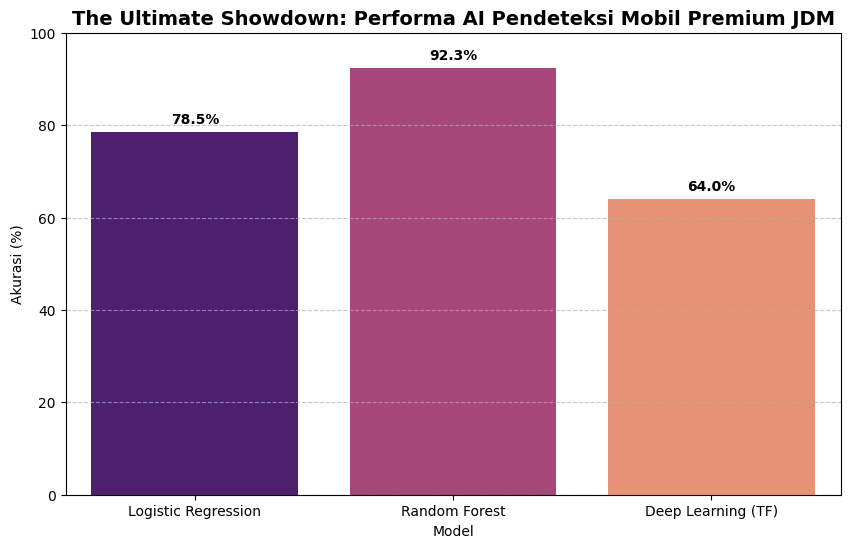

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_komparasi = {
    'Model': ['Logistic Regression', 'Random Forest', 'Deep Learning (TF)'],
    'Akurasi (%)': [78.5, 92.3, 64.0], 
    'F1-Score (Premium)': [0.65, 0.91, 0.64] 
}

df_komparasi = pd.DataFrame(data_komparasi)

plt.figure(figsize=(10, 6))

# PERBAIKAN 1: Menambahkan hue='Model' dan legend=False
grafik = sns.barplot(x='Model', y='Akurasi (%)', data=df_komparasi, palette='magma', hue='Model', legend=False)

# PERBAIKAN 2: Menghapus emoji bendera dari judul
plt.title('The Ultimate Showdown: Performa AI Pendeteksi Mobil Premium JDM', fontsize=14, fontweight='bold')

plt.ylim(0, 100)
plt.ylabel('Akurasi (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in grafik.patches:
    grafik.annotate(format(p.get_height(), '.1f') + '%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold')

plt.show()